# Stochastische Prozesse

## Vertiefung


### Übersicht

1. Monte-Carlo-Simulation
2. Simulated Annealing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1. Monte-Carlo-Simulation

Monte-Carlo-Simulation ist eine grosse Klasse von Methoden, die Fragestellungen mithilfe einer grossen Anzahl Zufallsexperimenten beantworten.

Beispiele:

- Bestimmen von statistische Eigenschaften von Zufallsprozessen, z.B. [Markow-Chain-Monte-Carlo-Verfahren (MCMC)](https://de.wikipedia.org/wiki/MCMC-Verfahren).
- Resampling von Daten, um statistische Eigenschaften zu bestimmen, z.B. [Bootstrapping](https://de.wikipedia.org/wiki/Bootstrapping-Verfahren).
- Stochastisches Sampling der Zielfunktion eines Optimierungsproblems, siehe [Simulated Annealing](https://de.wikipedia.org/wiki/Simulated_Annealing) im Teil 2.

#### a) Markow-Ketten mit diskreten Zuständen


- Zustandsverlauf
- Häufigkeitsverteilung der Zustände über einen langen Zeitraum
- Häufigkeitsverteilung über viele Realisierungen

Wir betrachten das folgelnde Markow-Ketten-Modell mit 3 Zuständen:

> ![fastfood.png](fastfood.png)
>
> Normalized Nerd. (2020, Oktober 25). *Markov Chains Clearly Explained! Part—1* [Videoaufnahme]. https://www.youtube.com/watch?v=i3AkTO9HLXo

Ziele

1. Schätzung der stationären Verteilung durch Simulation
2. Bestimmung der Aufenthaltswahrscheinlichkeit in den einzelnen Zuständen durch Monte-Carlo-Simulation


Für die Simulation des Markow-Ketten-Modells nutzen wir eine Übergangsmatrix, welche die Wahrscheinlichkeiten der Übergänge zwischen den Zuständen beschreibt:

$$
M = \begin{pmatrix}
    0.2 & 0.6 & 0.2 \\
    0.3 & 0 & 0.7 \\
    0.5 & 0 & 0.5
\end{pmatrix}
$$

$M_{ij}$ ist die Wahrscheinlichkeit, dass das System in einem Zeitschritt $\Delta t$ vom Zustand $i$ in den Zustand $j$ wechselt.

In [2]:
states = np.array([0, 1, 2])
state_names = np.array(["Burger", "Pizza", "Hotdog"])
transition_matrix = np.array(
    [
        [0.2, 0.6, 0.2],
        [0.3, 0.0, 0.7],
        [0.5, 0.0, 0.5],
    ]
)


def markov_next(current_state, rng):
    return rng.choice(states, p=transition_matrix[current_state])


def markov_process(n, initial_state=None, seed=None):
    rng = np.random.default_rng(seed)
    state = initial_state if initial_state is not None else rng.choice(states)
    chain = [state]
    for _ in range(n):
        state = markov_next(state, rng)
        chain.append(state)
    return np.array(chain)


markov_process(10, initial_state=0)

array([0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 2])

##### Zustandsverlauf

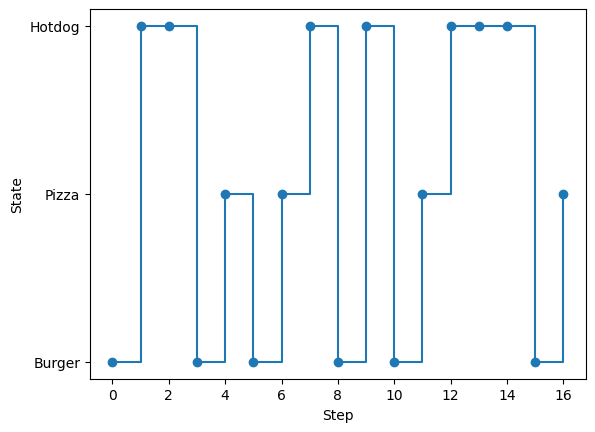

In [3]:
chain = markov_process(16)

plt.step(chain, "o-", where="post")
plt.yticks(states, state_names)
plt.xlabel("Step")
plt.ylabel("State")
plt.show()

##### Aufenthaltswahrscheinlichkeit über einen langen Verlauf

In [4]:
n_steps = 100
chain = markov_process(n_steps)
frequencies = pd.Series(chain).value_counts(normalize=True).sort_index()
frequencies

0    0.356436
1    0.207921
2    0.435644
Name: proportion, dtype: float64

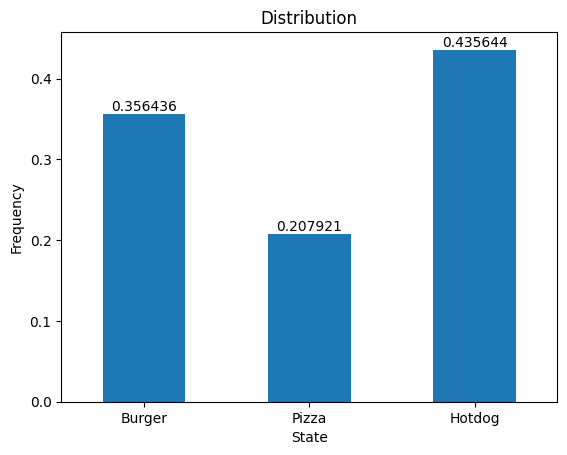

In [5]:
ax = frequencies.plot(kind="bar", rot=0)
ax.set_ylabel("Frequency")
ax.set_xlabel("State")
ax.set_xticks(states)
ax.set_xticklabels(state_names)
ax.set_title("Distribution")
ax.bar_label(ax.containers[0])
plt.show()

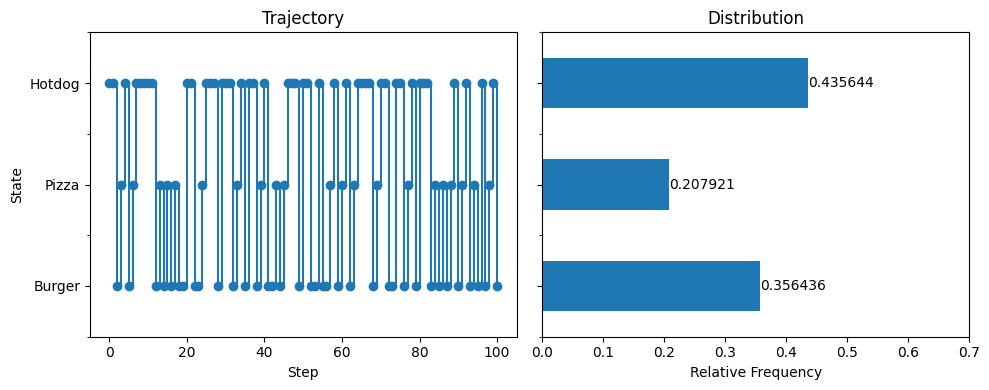

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ax1.step(chain, "o-", where="post")
ax1.set_title("Trajectory")
ax1.set_xlabel("Step")
ax1.set_ylabel("State")
ax1.set_yticks(states, state_names)

frequencies.plot(kind="barh", ax=ax2)
ax2.set_title("Distribution")
ax2.set_xlabel("Relative Frequency")
ax2.set_yticks(states, state_names)
ax2.set_ylabel("State")

ax2.bar_label(ax2.containers[0])
ax2.set_xlim(0, 0.7)

plt.tight_layout()
plt.show()

##### Aufenthaltswahrscheinlichkeit nach $t$ Schritten

Nun bestimmen wir die Wahrscheinlichkeit, dass sich das System nach $t$ Schritten in einem der Zustände befindet. Dazu führen wir eine Monte-Carlo-Simulation durch, indem wir viele Markow-Ketten simulieren.

In [7]:
n_steps = 10
n_chains = 10000
initial_state = 0

chains = np.array([markov_process(n_steps, initial_state) for _ in range(n_chains)])
chains

array([[0, 1, 2, ..., 0, 1, 2],
       [0, 0, 1, ..., 2, 0, 2],
       [0, 1, 2, ..., 2, 0, 2],
       ...,
       [0, 2, 0, ..., 2, 0, 1],
       [0, 1, 2, ..., 0, 1, 2],
       [0, 1, 2, ..., 1, 0, 1]], shape=(10000, 11))

Dann bestimmen wir die relativen Häufigkeiten der Zustände für alle Zeitschritte $t$.

In [8]:
df_frequencies = pd.DataFrame(
    {
        step: pd.Series(state_names[chains[:, step]]).value_counts(normalize=True)
        for step in range(chains.shape[1])
    }
).T
df_frequencies

,Burger,Hotdog,Pizza
0,1.0000,NaN,NaN
1,0.2046,0.1990,0.5964
2,0.3133,0.5604,0.1263
3,0.3759,0.4334,0.1907
4,0.3551,0.4248,0.2201
5,0.3406,0.4427,0.2167
6,0.3550,0.4410,0.2040
7,0.3521,0.4365,0.2114
8,0.3558,0.4367,0.2075
9,0.3577,0.4289,0.2134


Diese stellen wir dar.

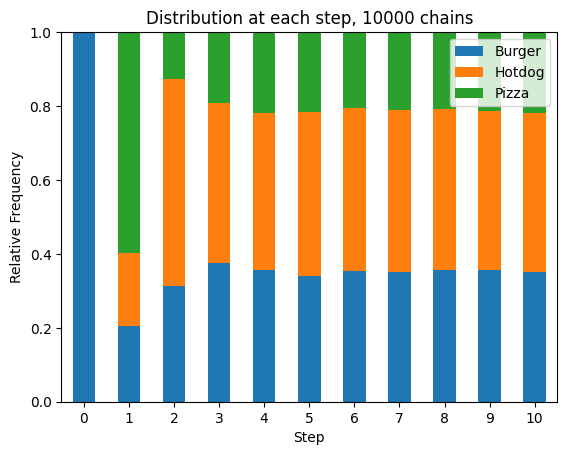

In [9]:
df_frequencies.plot(
    kind="bar",
    stacked=True,
    title=f"Distribution at each step, {n_chains} chains",
    xlabel="Step",
    ylabel="Relative Frequency",
    rot=0,
)
plt.show()

Man sieht, dass die Verteilung nach wenigen Schritten um einen Gleichgewichtszustand schwankt.

Die Verteilung konvergiert gegen die stationäre Verteilung. Je mehr Markow-Ketten man simuliert, desto schneller konvergiert die Verteilung.

In einfachen Fällen kann man die stationäre Verteilung analytisch bestimmen. In komplexeren Systemen kann man sie mit Hilfe der Monte-Carlo-Simulation bestimmen.

#### b) Markow-Ketten mit kontinuierlichen Zuständen

Der Zustandsraum einer Markow-Kette kann natürlich auch kontinuierlich sein. Ausgehend von einem Startwert $x_0\in\mathbb{R}$, soll nun ein Random Walk simuliert werden, der in jedem Schritt eine Zufallszahl aus einer Normalverteilung mit Mittelwert `mu=0` und Standardabweichung `sigma=1` zum letzten Zustand addiert.

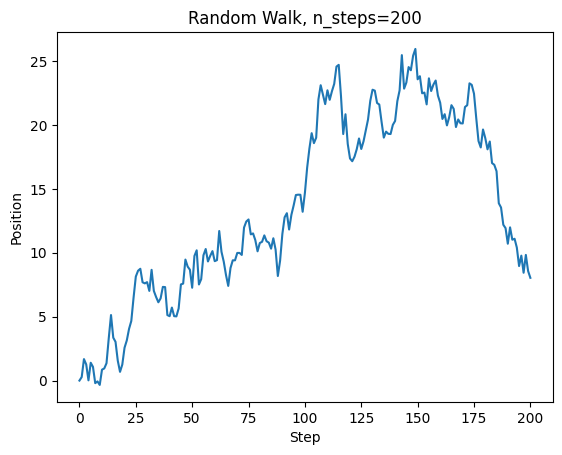

In [10]:
def random_walk(n, x0=0, seed=None, mu=0, sigma=1):
    rng = np.random.default_rng(seed)
    steps = rng.normal(mu, sigma, n)
    steps = np.hstack((x0, steps))
    return np.cumsum(steps)


n_steps = 200
walk = random_walk(n_steps)

plt.plot(walk)
plt.xlabel("Step")
plt.ylabel("Position")
plt.title(f"Random Walk, n_steps={n_steps}")
plt.show()

Auch hier können wir die Aufenthaltswahrscheinlichkeit nach $t$ Schritten bestimmen, indem wir viele Realisierungen des Random Walks simulieren.

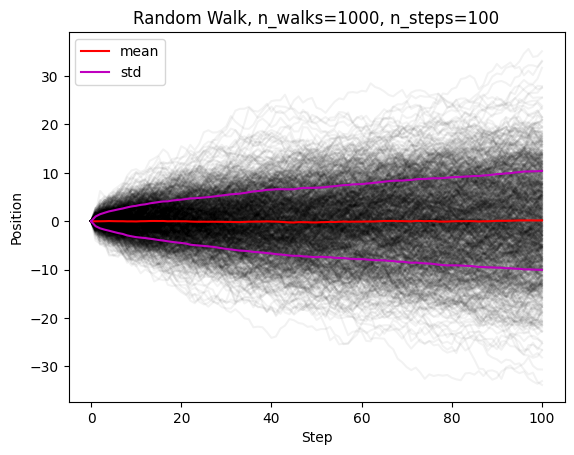

In [11]:
n_steps = 100
n_walks = 1000
walks = np.array([random_walk(n_steps) for _ in range(n_walks)])

plt.plot(walks.T, "k", alpha=0.05)
plt.plot(walks.mean(axis=0), "r", label="mean")
plt.plot(walks.mean(axis=0) + walks.std(axis=0), "m", label="std")
plt.plot(walks.mean(axis=0) - walks.std(axis=0), "m")
plt.xlabel("Step")
plt.ylabel("Position")
plt.title(f"Random Walk, n_walks={n_walks}, n_steps={n_steps}")
plt.legend()
plt.show()

### 2. Simulated Annealing

[Simulated Annealing](https://de.wikipedia.org/wiki/Simulated_Annealing) ist ein stochastisches Optimierungsverfahren, das auf verschiedenste Probleme angewendet werden kann. Stochastisch bedeutet hier, dass bei der Suche des Optimums Zufallszahlen verwendet werden, um den Lösungsraum $D$ zu durchsuchen. Als eine Konsequenz kann man nicht sicher sein, ob man je das globale Optimum wirklich findet. Solche Verfahren werden dann genutzt, wenn exakte Methoden nicht anwendbar sind, weil der Lösungsraum zu gross ist oder die Zielfunktion zu komplex oder nicht differenzierbar ist.

Das gesuchte Optimum kann ein globales Minimum oder Maximum einer (skalaren) Zielfunktion $f$ sein. Hier formulieren wir es als ein Minimierungsproblem, ansonsten könnten wir einfach das Minimum von $g(x)=-f(x)$ suchen.

$$
\text{Suche}\qquad
x_\text{opt} = \operatorname*{argmin}_{x \in D} f(x)
\qquad \text{für} \qquad
f: D \rightarrow \mathbb{R}
$$

Der Lösungsraum $D$ kann eine Teilmenge des Vektorraums $\mathbb{R}^n$ sein, aber auch eine Menge von diskreten Werten. Die Funktion $f$ muss nicht stetig oder differenzierbar sein.

Vorgehen:
1. Startpunkt $x_i \in D$ für $i=0$ wählen, evtl. zufällig.
2. Neuen Punkt $x_\ast$ zufällig aus der Umgebung von $x_i$ ziehen.
3. Falls $f(x_\ast) < f(x_i)$, dann $x_\ast$ als neuen Punkt wählen, also $x_{i+1}=x_\ast$. Sonst mit Wahrscheinlichkeit $p$ als neuen Punkt wählen, oder verwerfen.
1. Falls Abbruchkriterium erfüllt, dann $x_i$ als Lösung zurückgeben, sonst mit $i=i+1$ zu 2.

Die Akzeptanzwahrscheinlichkeit $p$ wird häufig als [Boltzmann-Verteilung](https://de.wikipedia.org/wiki/Boltzmann-Statistik) gewählt:

$$ p = \exp\left(-\frac{f(x_\ast)-f(x_i)}{T}\right) $$

- Je schlechter der Lösungsvorschlag $x_\ast$, d.h. je grösser die Differenz $f(x_\ast)-f(x_i)$, desto kleiner die Akzeptanzwahrscheinlichkeit
- Je höher die Temperatur $T$, desto grösser die Akzeptanzwahrscheinlichkeit
- Die Temperatur wird mit der Zeit (Anzahl Iterationen) abgesenkt, um die Akzeptanzwahrscheinlichkeit zu verringern.

Die Qualität und Effizienz des Verfahrens hängt stark von der Wahl der Umgebung des Lösungsvorschlags $x_i$ ab. Die Umgebung sollte so gewählt werden, dass die Wahrscheinlichkeit, einen besseren Punkt zu finden, nicht zu klein ist, und gleichzeitig die Möglichkeit besteht, den gesamten Lösungsraum zu durchsuchen und so lokalen Extremstellen zu entkommen.

Videos:

- ["Simulated Annealing" - Andreas Müller](https://www.youtube.com/watch?v=iaq_Fpr4KZc)

#### Beispiel 1: Minimierung einer Funktion in 1D

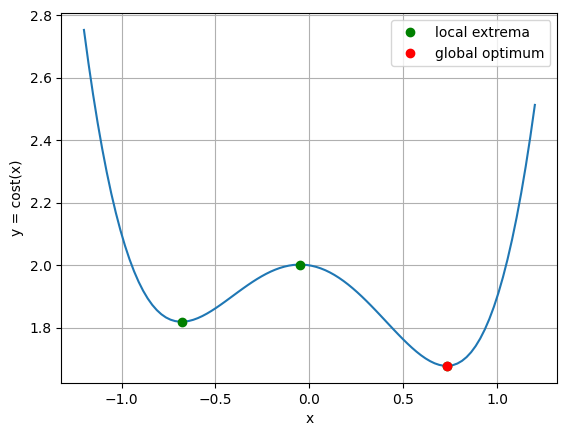

In [12]:
def f(x):
    return x**4 - x**2 - 0.1 * x + 2


x = np.linspace(-1.2, 1.2, 100)
y = f(x)

x_extrema = np.array((-0.680639, -0.0502538, 0.730893))
y_extrema = f(x_extrema)
x_optimum = x_extrema[np.argmin(y_extrema)]
y_optimum = f(x_optimum)

plt.plot(x, y)
plt.plot(x_extrema, y_extrema, "go", label="local extrema")
plt.plot(x_optimum, y_optimum, "ro", label="global optimum")
plt.xlabel("x")
plt.ylabel("y = cost(x)")
plt.grid()
plt.legend()
plt.show()

#### Schritt 1: Random Walk im Lösungsraum

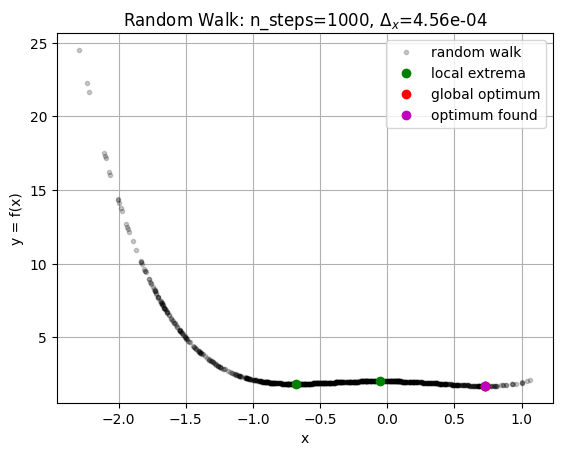

In [13]:
rng = np.random.default_rng(123456789)
n_steps = 1000
sigma = 0.1

xi = -0.5
yi = f(xi)
res = [(xi, yi)]

# Random Walk
for _ in range(n_steps):
    xi = rng.normal(xi, sigma)
    yi = f(xi)
    res.append((xi, yi))

x, y = np.array(res).T
i_best = np.argmin(y)
x_best = x[i_best]
y_best = y[i_best]
Dx = np.abs(x_best - x_optimum)

plt.plot(x, y, "k.", alpha=0.2, label="random walk")
plt.plot(x_extrema, y_extrema, "go", label="local extrema")
plt.plot(x_optimum, y_optimum, "ro", label="global optimum")
plt.plot(x_best, y_best, "mo", label="optimum found")
plt.xlabel("x")
plt.ylabel("y = f(x)")
plt.title(f"Random Walk: n_steps={n_steps}, $\\Delta_x$={Dx:.2e}")
plt.grid()
plt.legend()
plt.show()

Beobachtung: Der Random Walk im Lösungsraum bewegt sich zwar dort, wo die Funktion $f$ lokale Extrema hat, aber er konvergiert nicht zum Minimum. Ändert man den Startpunkt, so findet er das Minimum wommöglich nicht.

Er muss also etwas in die richtige Richtung gelenkt werden.

#### Schritt 2: Nur bessere Punkte akzeptieren

Nun werden nur diejenigen Punkte akzeptiert, die besser sind als der aktuelle Punkt. Der Random Walk bewegt sich nun in die Richtung des Minimums.

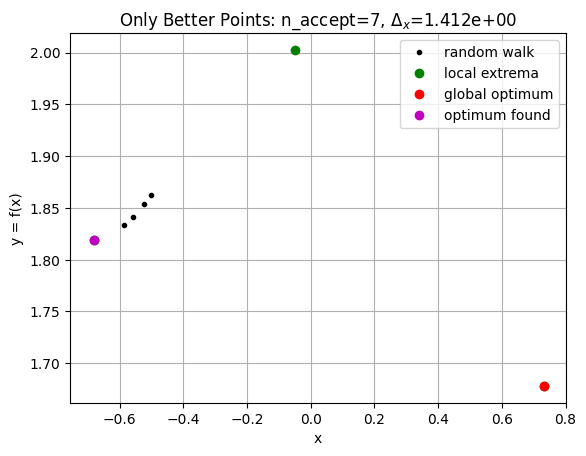

In [14]:
rng = np.random.default_rng(123456789)
n_steps = 1000
sigma = 0.1

xi = -0.5
yi = f(xi)
res = [(xi, yi)]

# Only accept better points
for _ in range(n_steps):
    x_trial = rng.normal(xi, sigma)
    y_trial = f(x_trial)
    if y_trial < yi:
        xi = x_trial
        yi = y_trial
        res.append((xi, yi))

x, y = np.array(res).T
i_best = np.argmin(y)
x_best = x[i_best]
y_best = y[i_best]
Dx = np.abs(x_best - x_optimum)
n_accept = len(x) - 1

plt.plot(x, y, "k.", label="random walk")
plt.plot(x_extrema, y_extrema, "go", label="local extrema")
plt.plot(x_optimum, y_optimum, "ro", label="global optimum")
plt.plot(x_best, y_best, "mo", label="optimum found")
plt.xlabel("x")
plt.ylabel("y = f(x)")
plt.grid()
plt.legend()
plt.title(f"Only Better Points: n_accept={n_accept}, $\\Delta_x$={Dx:.3e}")
plt.show()

Beobachtung: Der Random Walk kommt nur sehr langsam vorwärts, weil zu viele Schritte nicht akzeptiert werden. Es besteht die Gefahr, dass der Random Walk in dem lokalen Minimum bei $x=-0.680639$ stecken bleibt. Erwöht man die Schrittweite $\sigma$, so kann es sein, dass ein lokales Maximum übersprungen und das globale Maximum gefunden wird.

#### Schritt 3: Akzeptanzwahrscheinlichkeit

Schliesslich soll mit einer gewissen Wahrscheinlichkeit, ein Vorschlag auch dann akzeptiert werden, wenn er eigentlich schlechter ist, als der letzte. Die Akzeptanzwahrscheinlichkeit wird mit der Temperatur $T$ gesteuert, so dass sie mit der Zeit abnimmt, damit der Algorithmus konvergiert.

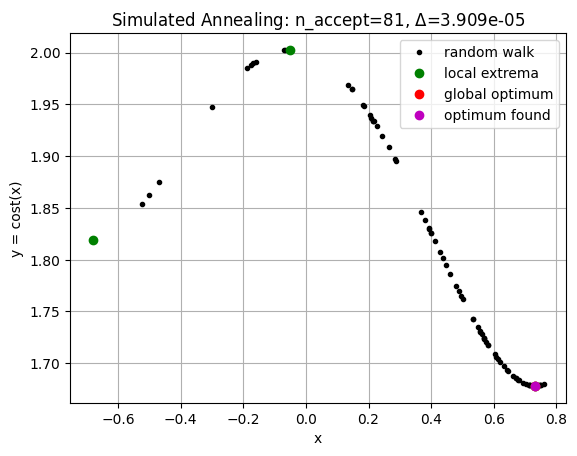

In [15]:
def acceptance_probability(new_cost, old_cost, T):
    return np.exp(-(new_cost - old_cost) / T)


rng = np.random.default_rng(123456789)
n_steps = 1000
sigma = 0.1

Ti = 10
xi = -0.5
yi = f(xi)
x_best = xi
y_best = yi
res = [(xi, yi, x_best, y_best, Ti)]

# Simulated Annealing (with acceptance probability)
for _ in range(n_steps):
    Ti = Ti / 1.1
    x_trial = rng.normal(xi, sigma)
    y_trial = f(x_trial)
    if y_trial < yi or rng.random() < acceptance_probability(y_trial, yi, Ti):
        xi = x_trial
        yi = y_trial
        if yi < y_best:
            x_best = xi
            y_best = yi
        res.append((xi, yi, x_best, y_best, Ti))

x, y, x_best, y_best, Ti = np.array(res).T
delta = np.abs(x_best[-1] - x_optimum)
n_accept = len(x) - 1


plt.plot(x, y, "k.", label="random walk")
plt.plot(x_extrema, y_extrema, "go", label="local extrema")
plt.plot(x_optimum, y_optimum, "ro", label="global optimum")
plt.plot(x_best[-1], y_best[-1], "mo", label="optimum found")
plt.xlabel("x")
plt.ylabel("y = cost(x)")
plt.grid()
plt.legend()
plt.title(f"Simulated Annealing: n_accept={n_accept}, $\\Delta$={delta:.3e}")
plt.show()

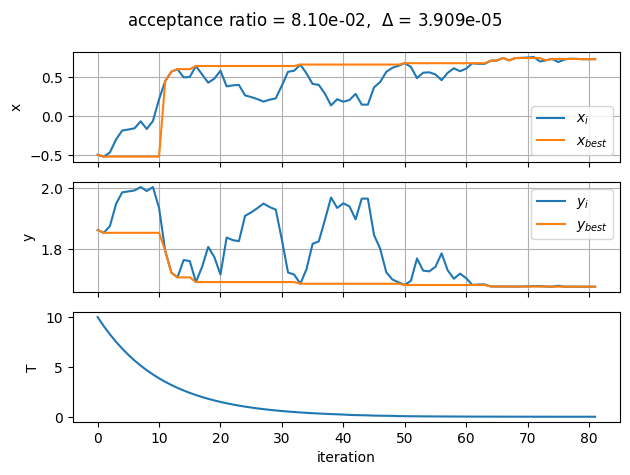

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
ax1.plot(x, label="$x_i$")
ax1.plot(x_best, label="$x_{best}$")
ax1.set_ylabel("x")
ax1.legend()
ax1.grid()
ax2.plot(y, label="$y_i$")
ax2.plot(y_best, label="$y_{best}$")
ax2.set_ylabel("y")
ax2.legend()
ax2.grid()
ax3.plot(Ti, label="T")
ax3.set_ylabel("T")
ax3.set_xlabel("iteration")
plt.suptitle(f"acceptance ratio = {n_accept / n_steps:.2e},  $\\Delta$ = {delta:.3e}")
plt.tight_layout()
plt.show()